In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Andjela\Documents\SkladistenjeProjekat\archive\yellow_tripdata_2015-01_OCISCEN.csv')

print(f"Broj redova: {df.shape[0]:,}")
print(f"Broj kolona: {df.shape[1]}")
print(df.head())

Broj redova: 12,657,278
Broj kolona: 21
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2015-01-15 19:05:39   2015-01-15 19:23:42                1   
1         1  2015-01-10 20:33:38   2015-01-10 20:53:28                1   
2         1  2015-01-10 20:33:38   2015-01-10 20:43:41                1   
3         1  2015-01-10 20:33:39   2015-01-10 20:35:31                1   
4         1  2015-01-10 20:33:39   2015-01-10 20:52:58                1   

   trip_distance  pickup_longitude  pickup_latitude  RateCodeID  \
0           1.59        -73.993896        40.750111           1   
1           3.30        -74.001648        40.724243           1   
2           1.80        -73.963341        40.802788           1   
3           0.50        -74.009087        40.713818           1   
4           3.00        -73.971176        40.762428           1   

  store_and_fwd_flag  dropoff_longitude  ...  payment_type  fare_amount  \
0                  N         -7

<class 'pandas.DataFrame'>
RangeIndex: 12657278 entries, 0 to 12657277
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
 19  duration_minutes       float64
 20  trip_duration_minutes  float64
dtypes: float64(14), int64(4), str(3)
memory usage: 2.0 GB
None
    

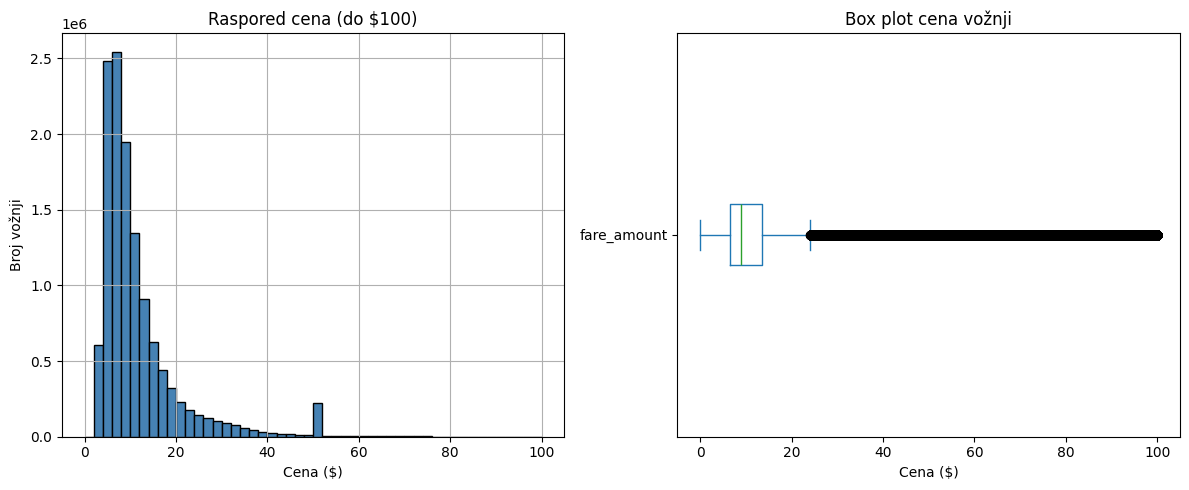

Vožnje sa cenom 0: 0
Vožnje sa cenom između 0 i 1$: 718


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 1. Pogledaj osnovne informacije
print(df.info())
print(df.describe())

# Bolji način da vidiš raspored cena - ograniči prikaz
plt.figure(figsize=(12,5))

# 1. Histogram samo za vožnje do $100 (98% podataka)
plt.subplot(1,2,1)
df[df['fare_amount'] <= 100]['fare_amount'].hist(bins=50, edgecolor='black', color='steelblue')
plt.title('Raspored cena (do $100)')
plt.xlabel('Cena ($)')
plt.ylabel('Broj vožnji')

# 2. Box plot (bolji za uočavanje outlier-a)
plt.subplot(1,2,2)
df[df['fare_amount'] <= 100]['fare_amount'].plot(kind='box', vert=False)
plt.title('Box plot cena vožnji')
plt.xlabel('Cena ($)')

plt.tight_layout()
plt.show()

# 3. Proveri koliko imaš čudnih vrednosti
print("Vožnje sa cenom 0:", (df['fare_amount'] == 0).sum())
print("Vožnje sa cenom između 0 i 1$:", ((df['fare_amount'] > 0) & (df['fare_amount'] < 1)).sum())

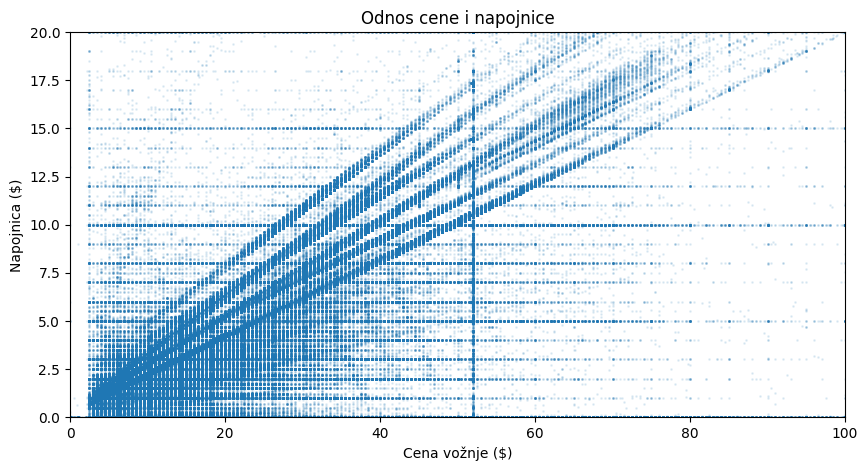

Procenat vožnji sa napojnicom: 59.9%
Prosečna napojnica: 12.8% od cene


In [4]:
# 1. Vidi odnos cene i napojnice
plt.figure(figsize=(10,5))
plt.scatter(df['fare_amount'], df['tip_amount'], alpha=0.1, s=1)
plt.xlabel('Cena vožnje ($)')
plt.ylabel('Napojnica ($)')
plt.title('Odnos cene i napojnice')
plt.xlim(0, 100)
plt.ylim(0, 20)
plt.show()

# 2. Procentualno koliko ljudi uopšte daje napojnicu
tip_percentage = (df['tip_amount'] > 0).mean() * 100
print(f"Procenat vožnji sa napojnicom: {tip_percentage:.1f}%")

# 3. Prosečna napojnica kao procenat od cene
df['tip_percent'] = (df['tip_amount'] / df['fare_amount'] * 100).replace([float('inf'), -float('inf')], 0)
avg_tip_percent = df[df['tip_percent'] < 100]['tip_percent'].mean()  # izbaci ekstreme
print(f"Prosečna napojnica: {avg_tip_percent:.1f}% od cene")

Vožnje sa 0 minuta: 0
Broj redova pre čišćenja brzine: 12,657,278
Broj redova posle čišćenja brzine: 12,607,448
Uklonjeno: 49,830 sumnjivih vožnji

Najsporije vožnje (top 5) posle čišćenja:
          trip_distance  duration_minutes  avg_speed_mph
12044764          11.37       1363.583333       0.500299
6480303            0.50         59.933333       0.500556
4022112           11.79       1413.100000       0.500602
2373326            0.23         27.566667       0.500605
11888664           0.10         11.983333       0.500695

Najbrže vožnje (top 5) posle čišćenja:
          trip_distance  duration_minutes  avg_speed_mph
5082127             2.3          1.383333      99.759036
2099865             1.8          1.083333      99.692308
7751566             4.7          2.833333      99.529412
9534591             1.9          1.150000      99.130435
10249528           26.7         16.166667      99.092784

=== STATISTIKA BRZINE ===
Prosečna brzina: 12.5 mph
Medijana brzine: 11.1 mph
Maksima

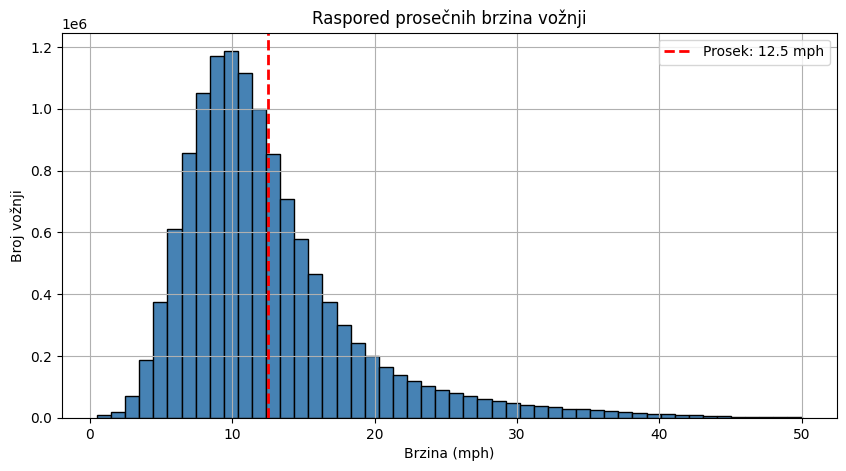

In [5]:
# 1. Konvertuj datetime kolone
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# 2. Dodaj nove korisne karakteristike
df['trip_hour'] = df['tpep_pickup_datetime'].dt.hour
df['trip_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['trip_month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = (df['tpep_pickup_datetime'].dt.dayofweek >= 5).astype(int)

# 3. Proveri ima li nula u trajanju
zero_duration = df[df['duration_minutes'] == 0]
print(f"Vožnje sa 0 minuta: {len(zero_duration):,}")

# 4. Izračunaj prosečnu brzinu (milja po satu)
df['avg_speed_mph'] = df['trip_distance'] / (df['duration_minutes'] / 60)
df['avg_speed_mph'] = df['avg_speed_mph'].replace([float('inf'), -float('inf')], 0)

# Izbaci vožnje sa nerealnom brzinom (preko 100 mph ili ispod 0.5 mph)
df_clean_speed = df[
    (df['avg_speed_mph'] > 0.5) & 
    (df['avg_speed_mph'] < 100) & 
    (df['duration_minutes'] > 1)  # vožnje kraće od 1 minuta su sumnjive
]

print(f"Broj redova pre čišćenja brzine: {len(df):,}")
print(f"Broj redova posle čišćenja brzine: {len(df_clean_speed):,}")
print(f"Uklonjeno: {len(df) - len(df_clean_speed):,} sumnjivih vožnji")

# Sada ponovo izračunaj najsporije i najbrže
df_clean_speed['avg_speed_mph'] = df_clean_speed['trip_distance'] / (df_clean_speed['duration_minutes'] / 60)

print("\nNajsporije vožnje (top 5) posle čišćenja:")
print(df_clean_speed.nsmallest(5, 'avg_speed_mph')[['trip_distance', 'duration_minutes', 'avg_speed_mph']])

print("\nNajbrže vožnje (top 5) posle čišćenja:")
print(df_clean_speed.nlargest(5, 'avg_speed_mph')[['trip_distance', 'duration_minutes', 'avg_speed_mph']])
# Bolji prikaz brzina (zaokružene vrednosti)
print("\n=== STATISTIKA BRZINE ===")
print(f"Prosečna brzina: {df_clean_speed['avg_speed_mph'].mean():.1f} mph")
print(f"Medijana brzine: {df_clean_speed['avg_speed_mph'].median():.1f} mph")
print(f"Maksimalna brzina: {df_clean_speed['avg_speed_mph'].max():.1f} mph")
print(f"Minimalna brzina: {df_clean_speed['avg_speed_mph'].min():.1f} mph")

# Histogram brzina
plt.figure(figsize=(10,5))
df_clean_speed[df_clean_speed['avg_speed_mph'] < 50]['avg_speed_mph'].hist(bins=50, edgecolor='black', color='steelblue')
plt.title('Raspored prosečnih brzina vožnji')
plt.xlabel('Brzina (mph)')
plt.ylabel('Broj vožnji')
plt.axvline(df_clean_speed['avg_speed_mph'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Prosek: {df_clean_speed["avg_speed_mph"].mean():.1f} mph')
plt.legend()
plt.show()

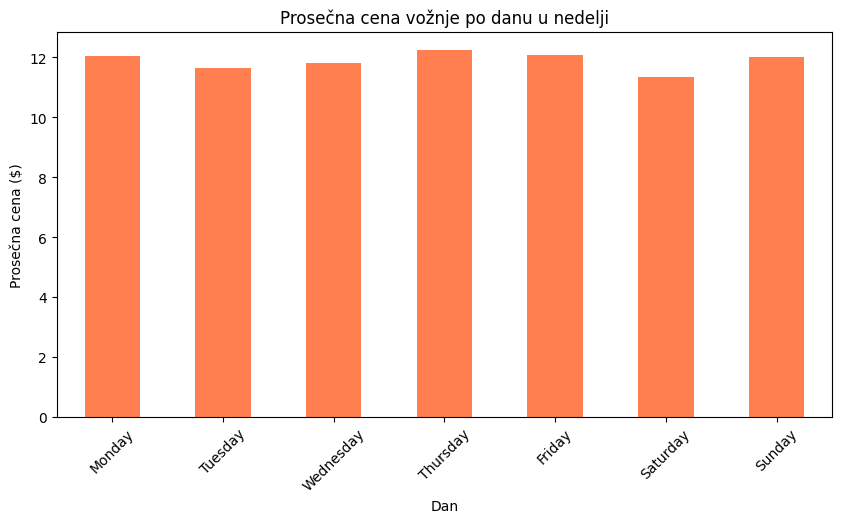

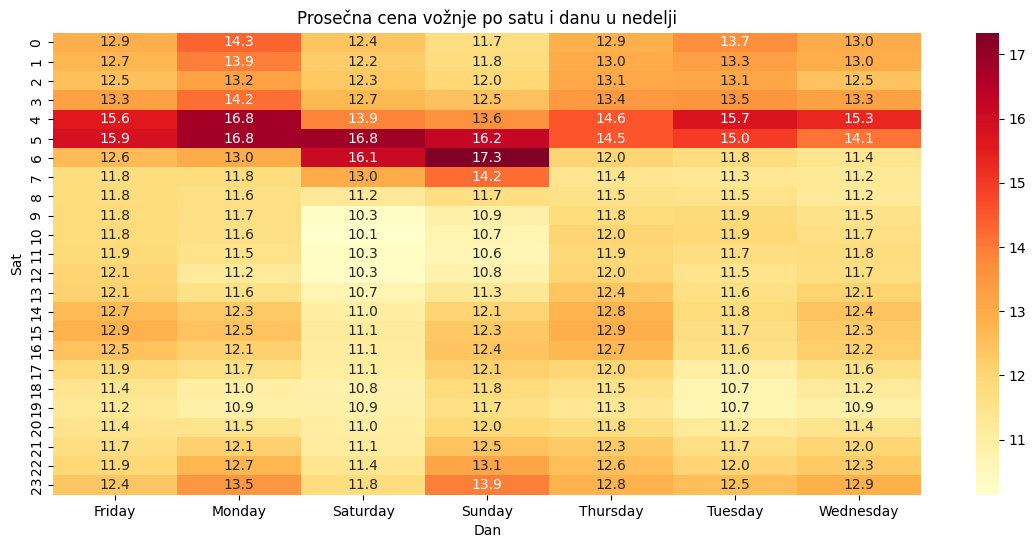

In [6]:
# 1. Vidi kako dan u nedelji utiče na cenu
df['day_of_week'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.day_name()
avg_fare_by_day = df.groupby('day_of_week')['fare_amount'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(10,5))
avg_fare_by_day.plot(kind='bar', color='coral')
plt.title('Prosečna cena vožnje po danu u nedelji')
plt.xlabel('Dan')
plt.ylabel('Prosečna cena ($)')
plt.xticks(rotation=45)
plt.show()

# 2. Kombinacija sata i dana (kad je najskuplje?)
df['hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
pivot_table = df.pivot_table(
    values='fare_amount', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Prosečna cena vožnje po satu i danu u nedelji')
plt.xlabel('Dan')
plt.ylabel('Sat')
plt.show()

Top 10 lokacija po zaradi:
                                  fare_amount  trip_distance  tip_amount
pickup_longitude pickup_latitude                                        
 0.000000        0.000000           2692269.5       2.709901    1.538599
-73.948639       40.744900            12611.5       2.813333    1.621633
-74.186302       40.693142             7879.6       2.374897    1.395683
-73.986717       40.722290             4590.5       2.347552    1.377855
-73.915123       40.743576             3519.3       2.574013    1.741217
-74.003143       40.727676             2631.4       2.638793    1.381336
-73.776733       40.645378             2437.5      16.226038    6.540566
-73.776718       40.645378             2346.0      15.748113    4.826038
-73.776703       40.645378             2242.5      14.496481    4.019259
                 40.645393             2240.5      15.886327    5.739796


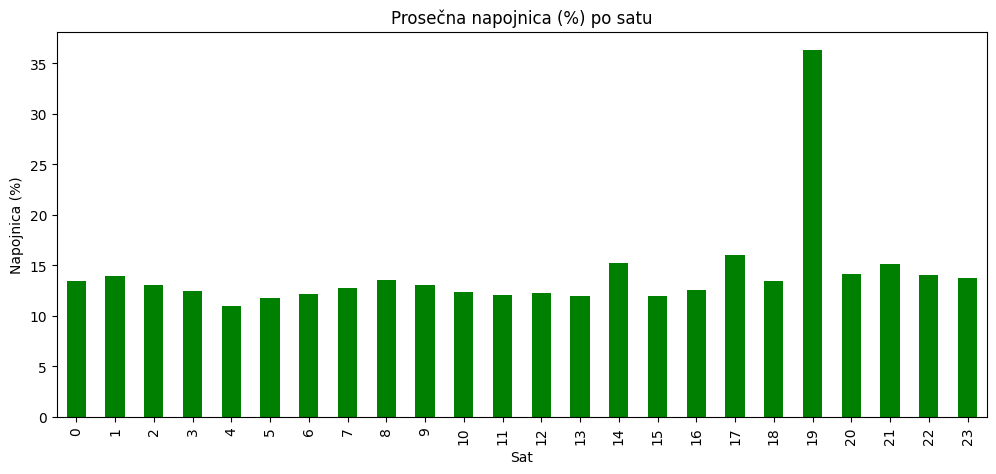


Napojnice po danu:
day_of_week
Monday       13.0
Tuesday      13.9
Wednesday    13.8
Thursday     13.1
Friday       14.4
Saturday     12.7
Sunday       24.4
Name: tip_percent, dtype: float64


In [7]:
# 1. Koje lokacije su najprofitabilnije?
top_pickups = df.groupby(['pickup_longitude', 'pickup_latitude']).agg({
    'fare_amount': 'sum',
    'trip_distance': 'mean',
    'tip_amount': 'mean'
}).sort_values('fare_amount', ascending=False).head(10)
print("Top 10 lokacija po zaradi:")
print(top_pickups)

# 2. Kako vreme utiče na napojnicu?
tip_by_hour = df.groupby('trip_hour')['tip_percent'].mean()
plt.figure(figsize=(12,5))
tip_by_hour.plot(kind='bar', color='green')
plt.title('Prosečna napojnica (%) po satu')
plt.xlabel('Sat')
plt.ylabel('Napojnica (%)')
plt.show()

# 3. Koji dani imaju najveće napojnice?
tip_by_day = df.groupby('day_of_week')['tip_percent'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print("\nNapojnice po danu:")
print(tip_by_day.round(1))